In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)

In [2]:
df_house = pd.read_csv('../data/processed/housing/ground_truth.csv')
df_adult = pd.read_csv('../data/processed/adult/ground_truth.csv')

**Выбираем столбцы для пропусков**

В датасете housing будем делать пропуски в median_income, total_rooms, housing_median_age. Для пропусков типа MAR нужны столбцы, от которых будут зависеть пропуски в выбранных столбцах. Будем выбирать эти столбцы на основе *feature importance* и *корреляций*.

In [3]:
# TODO сделать описание функции
def get_feature_importance(df, target_col):
    df_copy = df.copy()
    
    # кодируем категории
    for col in df_copy.select_dtypes(include=['object', 'string']).columns:
        le = LabelEncoder()
        df_copy[col] = le.fit_transform(df_copy[col].astype(str))
    
    X = df_copy.drop(columns=[target_col])
    y = df_copy[target_col]
    
    # выбираем модель
    if y.nunique() < 20:
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    else:
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    
    model.fit(X, y)

    return pd.Series(model.feature_importances_, index=X.columns)

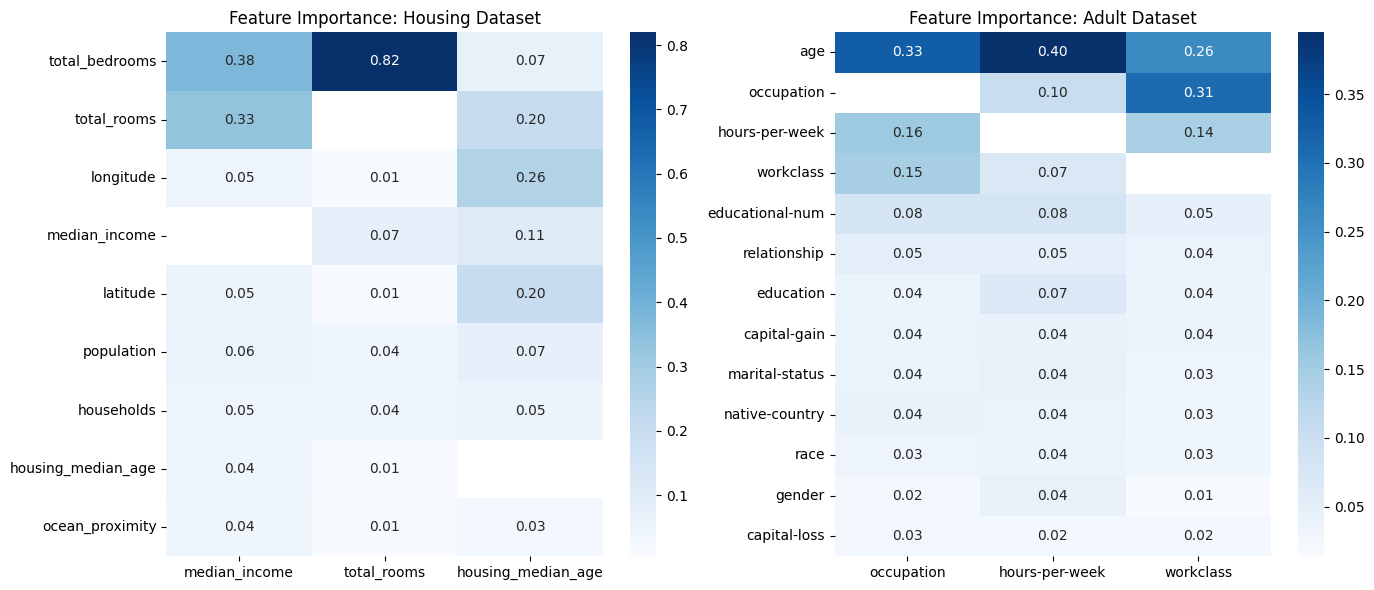

In [4]:
df_house = df_house.drop(columns=['median_house_value'])  # убираем целевые переменные, чтобы они не мешали в анализе важности признаков
df_adult = df_adult.drop(columns=['income', 'fnlwgt'])  # убираем целевую переменную, чтобы она не мешала в анализе важности признаков

dfs = {'housing': df_house, 
       'adult': df_adult}
targets = {'housing': ['median_income', 'total_rooms', 'housing_median_age'],
           'adult': ['occupation', 'hours-per-week', 'workclass']}

fig, axes = plt.subplots(1, 2, figsize=(14,6))  # 1 ряд, 2 колонки

for i, (dataset_name, df) in enumerate(dfs.items()):
    all_features = df.columns
    importance_table = pd.DataFrame(index=all_features)

    for target in targets[dataset_name]:
        importance = get_feature_importance(df, target)
        importance_table[target] = importance

    # округляем
    importance_table = importance_table.round(3)

    # сортируем по среднему значению
    importance_table['mean_importance'] = importance_table.mean(axis=1)
    importance_table = importance_table.sort_values(by='mean_importance', ascending=False)

    # убираем вспомогательный столбец
    importance_table = importance_table.drop(columns=['mean_importance'])

    sns.heatmap(importance_table, cmap='Blues', annot=True, fmt=".2f", ax=axes[i])
    axes[i].set_title("Feature Importance: " + dataset_name.capitalize() + " Dataset")

plt.tight_layout()  # чтобы заголовки и таблицы не наслаивались
plt.show()

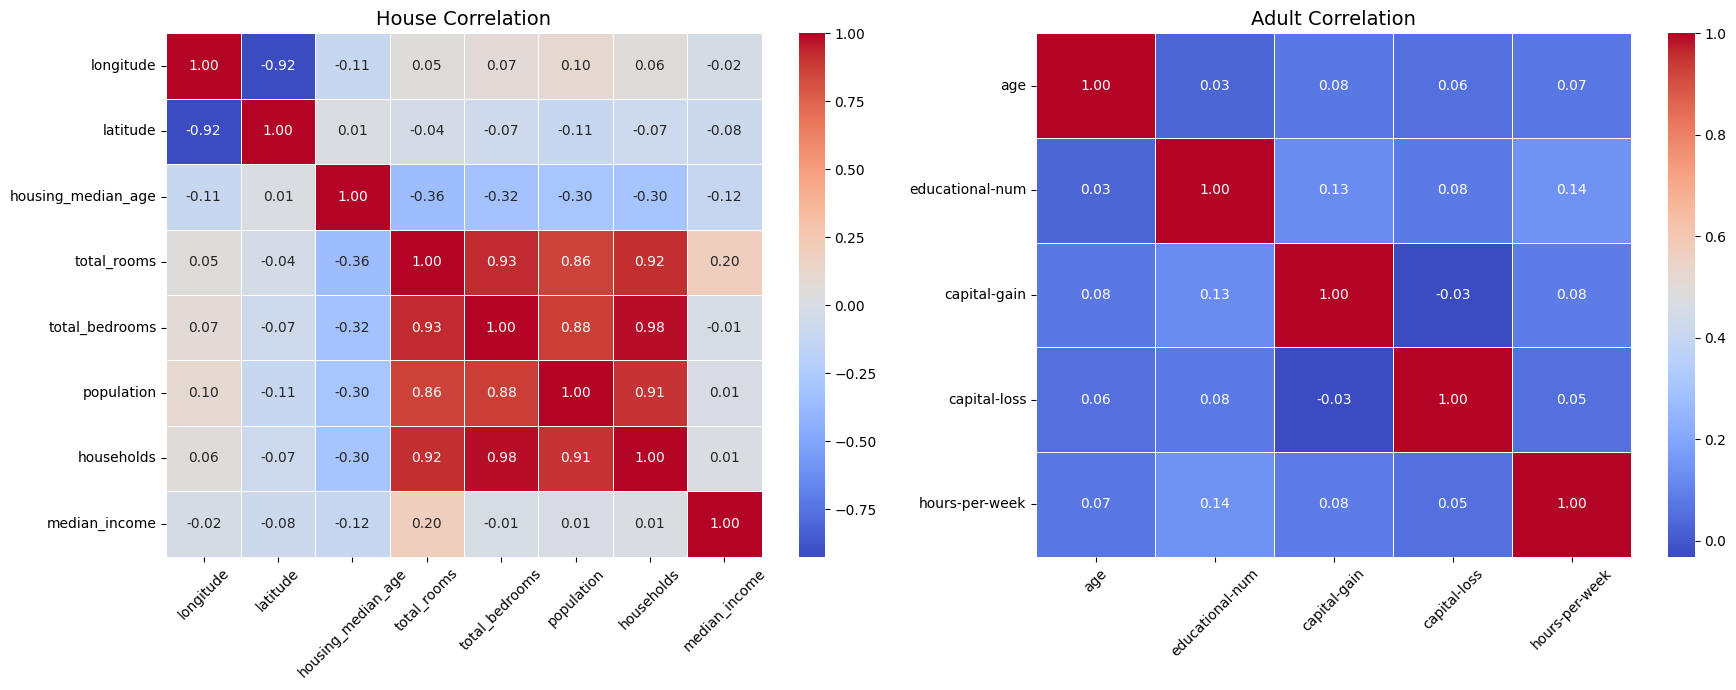

In [5]:
dfs = [
    (df_house.select_dtypes(include='number'), 'House'),
    (df_adult.select_dtypes(include='number'), 'Adult'),
]

fig, axes = plt.subplots(1, len(dfs), figsize=(18, 7))

for ax, (df_numeric, title) in zip(axes, dfs):
    sns.heatmap(
        df_numeric.corr(),
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'{title} Correlation', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

**Столбцы, в которых будут генерироваться пропуски типа MCAR и MAR для housing, в скобках указан столбец, от которого зависит пропуск MAR:**

median_income (total_rooms)

total_rooms (population)

housing_median_age (households)

**Столбцы, в которых будут генерироваться пропуски типа MCAR и MAR для adult, в скобках указан столбец, от которого зависит пропуск MAR:**

occupation (hours_per_week)

hours_per_week (age)

workclass (hours_per_week)